Load the dataset from Donlon 2025

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
data_path = '/Users/pablom.perez/Desktop/Linas-group/data/pulsars/data.csv'
df = pd.read_csv(data_path, skiprows=[1])
len(df)

53

Remove the duplicate entry

In [3]:
df = df[df["NAME"] != "J0737-3039B"].reset_index(drop=True)
print(len(df)) # Expect 52

52


The acceleration comes from PB in the binary pulsars and PS in the solitary pulsars

In [4]:
df["binary"] = df["PB"].notna()
df["alos"] = np.where(df["binary"], df["ALOS_PB"], df["ALOS_PS"])
df["alos_err"] = np.where(df["binary"], df["ALOS_PB_ERR"], df["ALOS_PS_ERR"])
print(df["binary"].value_counts())

binary
False    26
True     26
Name: count, dtype: int64


Plotting

Text(0, 0.5, '$a_{\\mathrm{los}}\\ \\mathrm{[mm\\,s^{-1}\\,yr^{-1}]}$')

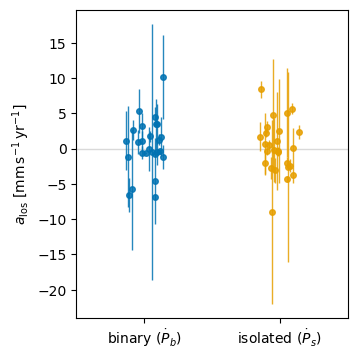

In [5]:
COL = {True: "#0072B2", False: "#E69F00"}   # binary blue, isolated orange
rng = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(3.5, 4))
for is_bin, x0 in [(True, 0), (False, 1)]:
    sub = df[df.binary == is_bin]
    x = x0 + rng.uniform(-0.15, 0.15, len(sub))
    ax.errorbar(x, sub.alos, yerr=sub.alos_err, fmt="o", ms=4,
                elinewidth=1, color=COL[is_bin], alpha=0.85)
ax.axhline(0, color="0.85", lw=1, zorder=0)
ax.set_xticks([0, 1], [r"binary ($\dot{P}_b$)", r"isolated ($\dot{P}_s$)"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel(r"$a_{\mathrm{los}}\ \mathrm{[mm\,s^{-1}\,yr^{-1}]}$")


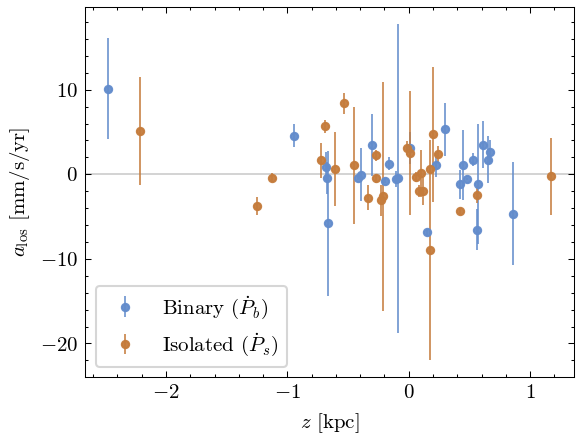

In [6]:
import scienceplots  # noqa: F401 — registers the styles
plt.style.use(["science", "no-latex"])
plt.rcParams["figure.dpi"] = 150   # crisp preview in the notebook

PAPER_PALETTE = ["#638ccc", "#c57c3c", "#ab62c0", "#72a555", "#ca5670"]
COL_BINARY, COL_ISOLATED = PAPER_PALETTE[:2]

df["z"] = df["DIST"] * np.sin(np.radians(df["GB"]))
fig, ax = plt.subplots(figsize=(4.2, 3.2))
for is_bin, lbl, c in [(True,  r"Binary ($\dot{P}_b$)",   COL_BINARY),
                       (False, r"Isolated ($\dot{P}_s$)", COL_ISOLATED)]:
    sub = df[df.binary == is_bin]
    ax.errorbar(sub.z, sub.alos, yerr=sub.alos_err, fmt="o", ms=3.5,
                elinewidth=0.8, color=c, alpha=.95, label=lbl)
ax.axhline(0, color="0.8", lw=0.8, zorder=0)
ax.set_xlabel(r"$z$ [kpc]")
ax.set_ylabel(r"$a_{\mathrm{los}}$ [mm/s/yr]")
ax.legend(frameon=True, loc="lower left")

fig.savefig("../../../accelerations-paper/figures/alos_vs_z.pdf", bbox_inches="tight")

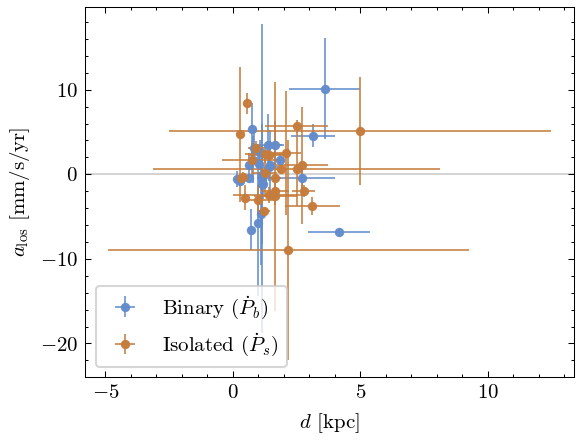

In [16]:
fig, ax = plt.subplots(figsize=(4.2, 3.2))
for is_bin, lbl, c in [(True,  r"Binary ($\dot{P}_b$)",   COL_BINARY),
                       (False, r"Isolated ($\dot{P}_s$)", COL_ISOLATED)]:
    sub = df[(df.binary == is_bin) & (df.DIST <= 8)]

    ax.errorbar(sub.DIST, sub.alos, xerr=sub.DIST_ERR, yerr=sub.alos_err,
                fmt="o", ms=3.5, elinewidth=0.8, color=c, alpha=.95, label=lbl)
ax.axhline(0, color="0.8", lw=0.8, zorder=0)
ax.set_xlabel(r"$d$ [kpc]")
ax.set_ylabel(r"$a_{\mathrm{los}}$ [mm/s/yr]")
ax.legend(frameon=True, loc="lower left")

fig.savefig("../../../accelerations-paper/figures/alos_vs_dist.pdf", bbox_inches="tight")


In [12]:
np.sort(df.DIST)

array([ 0.157,  0.268,  0.278,  0.324,  0.388,  0.476,  0.543,  0.625,
        0.649,  0.725,  0.769,  0.769,  0.806,  0.833,  0.909,  0.971,
        1.   ,  1.02 ,  1.08 ,  1.111,  1.136,  1.15 ,  1.15 ,  1.16 ,
        1.17 ,  1.22 ,  1.25 ,  1.25 ,  1.4  ,  1.429,  1.429,  1.429,
        1.47 ,  1.667,  1.667,  1.667,  1.667,  1.87 ,  1.887,  2.083,
        2.174,  2.5  ,  2.5  ,  2.7  ,  2.703,  2.778,  3.125,  3.15 ,
        3.6  ,  4.167,  5.   , 10.   ])